# Moving Average (MA)

## 1. Simple MA

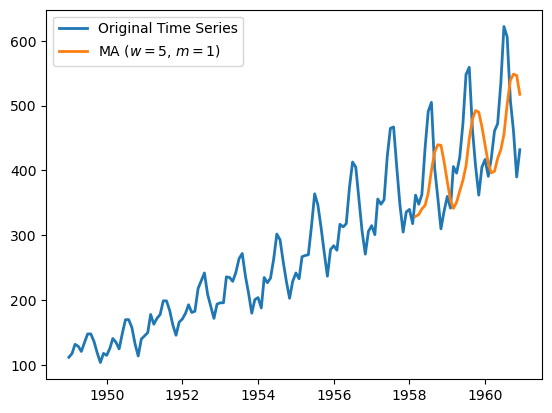

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.transformations.series.summarize import WindowSummarizer

y = load_airline()
# Matplotlib cannot plot PeriodIndex on the x-axis with default numpy conversion
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
X = y.to_frame()
target_col = X.columns[0]

# SMA with m=1: rolling mean then shift(1) — same as WindowSummarizer "mean" with [lag, window]
w = 5
ma_tf = WindowSummarizer(
    n_jobs=1,
    lag_feature={"mean": [[1, w]]},
    target_cols=[target_col],
)
Xt_ma = ma_tf.fit_transform(X)
moving_avg = Xt_ma[f"{target_col}_mean_1_{w}"]

plt.figure()
plt.plot(y, label="Original Time Series", linewidth=2)
plt.plot(moving_avg[110:], label=rf"MA ($w={w}$, $m=1$)", linewidth=2)

plt.legend()

# plt.savefig("SMA.pdf", bbox_inches='tight')

plt.show()


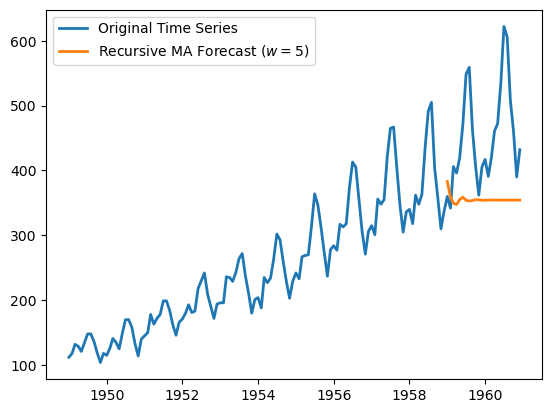

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline

y = load_airline()

if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()

# Parameters
w = 5
h = 24
forecast_start = 120

# Observed data up to time t
y_train = y.iloc[:forecast_start]

# Recursive SMA forecasting
history = list(y_train.values)
recursive_forecast = []

for m in range(1, h + 1):
    # Use the latest w values, which may include previous forecasts
    next_pred = sum(history[-w:]) / w
    recursive_forecast.append(next_pred)
    history.append(next_pred)

# Forecast index
freq = pd.infer_freq(y.index)

forecast_index = pd.date_range(
    start=y_train.index[-1],
    periods=h + 1,
    freq=freq
)[1:]

recursive_forecast = pd.Series(
    recursive_forecast,
    index=forecast_index,
    name=f"Recursive SMA Forecast (w={w})"
)

# Plot
plt.figure()

plt.plot(
    y,
    label="Original Time Series",
    linewidth=2
)

plt.plot(
    recursive_forecast,
    label=rf"Recursive MA Forecast ($w={w}$)",
    linewidth=2
)

plt.legend()

# plt.savefig("Recursive_SMA.pdf", bbox_inches="tight")

plt.show()

## 2. Exponential MA

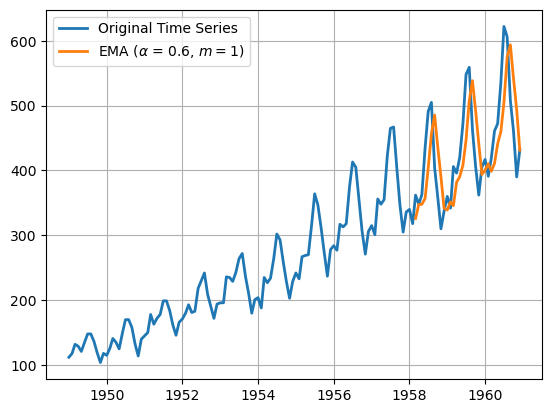

In [33]:
# Exponential Moving Average (EMWA) with alpha = 0.6 — sktime FunctionTransformer

import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.transformations.series.func_transform import FunctionTransformer

y = load_airline()
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
X = y.to_frame()

alpha = 0.6


def _ema_lagged_m1(X, alpha):
    """Same recursion as before; return level shifted by 1 (m=1)."""
    s = X.iloc[:, 0]
    emwa = s.astype(float).copy()
    emwa.iloc[0] = s.iloc[0]
    for t in range(1, len(s)):
        emwa.iloc[t] = alpha * s.iloc[t] + (1 - alpha) * emwa.iloc[t - 1]
    return emwa.shift(1).to_frame(name=X.columns[0])


ema_tf = FunctionTransformer(
    func=_ema_lagged_m1,
    kw_args={"alpha": alpha},
    check_inverse=False,
)
emwa_pred = ema_tf.fit_transform(X).iloc[:, 0]

plt.figure()
plt.plot(y, label="Original Time Series", linewidth=2)
plt.plot(emwa_pred[110:], label=f"EMA ($\\alpha$ = {alpha}, $m=1$)", linewidth=2)

plt.legend()
plt.grid(True)

plt.show()


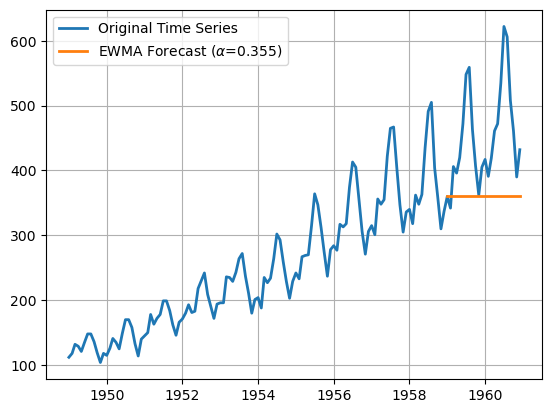

In [31]:
# Recursive Exponential Moving Average (EWMA) forecasting

import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline

y = load_airline()

if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()

alpha = 0.355
h = 24
forecast_start = 120

# Observed data up to time t
y_train = y.iloc[:forecast_start]

# Compute EWMA level M_t on observed data
emwa = y_train.astype(float).copy()
emwa.iloc[0] = y_train.iloc[0]

for t in range(1, len(y_train)):
    emwa.iloc[t] = alpha * y_train.iloc[t] + (1 - alpha) * emwa.iloc[t - 1]

M_t = emwa.iloc[-1]

# Recursive EWMA forecasting
recursive_forecast = []
M_star = M_t

for m in range(1, h + 1):
    # Forecast at t + m is the current EWMA level
    next_pred = M_star
    recursive_forecast.append(next_pred)

    # Update EWMA state using the forecast as the new value
    M_star = alpha * next_pred + (1 - alpha) * M_star

# Forecast index
freq = pd.infer_freq(y.index)

forecast_index = pd.date_range(
    start=y_train.index[-1],
    periods=h + 1,
    freq=freq
)[1:]

recursive_forecast = pd.Series(
    recursive_forecast,
    index=forecast_index,
    name=f"Recursive EWMA Forecast (alpha={alpha})"
)

# Plot
plt.figure()

plt.plot(
    y,
    label="Original Time Series",
    linewidth=2
)

plt.plot(
    recursive_forecast,
    label=rf"EWMA Forecast ($\alpha$={alpha})",
    linewidth=2
)

plt.legend()
plt.grid(True)

plt.show()

## 3. Double EMA

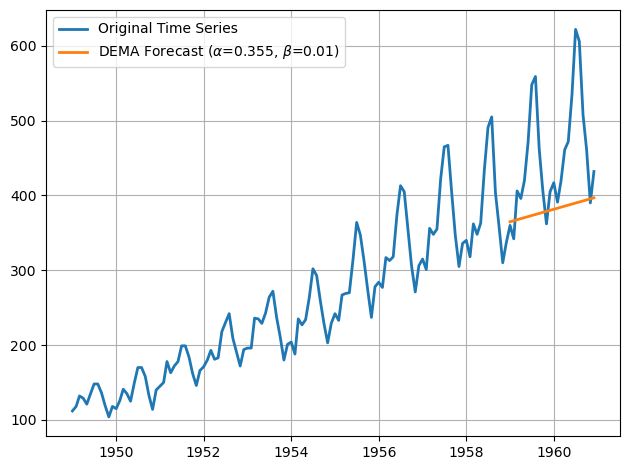

In [34]:
# Recursive Double Exponential Moving Average (DEMA) forecasting

import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline

y = load_airline()

if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()

alpha = 0.355
beta = 0.01
h = 24
forecast_start = 120

# Observed data up to time t
y_train = y.iloc[:forecast_start]

# Estimate level l_t and trend b_t using observed data
level = y_train.astype(float).copy()
trend = y_train.astype(float).copy()

level.iloc[0] = y_train.iloc[0]
trend.iloc[0] = 0.0

for i in range(1, len(y_train)):
    level.iloc[i] = (
        alpha * y_train.iloc[i]
        + (1 - alpha) * (level.iloc[i - 1] + trend.iloc[i - 1])
    )
    trend.iloc[i] = (
        beta * (level.iloc[i] - level.iloc[i - 1])
        + (1 - beta) * trend.iloc[i - 1]
    )

l_t = level.iloc[-1]
b_t = trend.iloc[-1]

# Recursive DEMA forecasting
recursive_forecast = []

l_star = l_t
b_star = b_t

for m in range(1, h + 1):
    # Forecast using current recursive level and trend
    next_pred = l_star + b_star
    recursive_forecast.append(next_pred)

    # Update recursive level and trend using the forecast as the new value
    new_l_star = (
        alpha * next_pred
        + (1 - alpha) * (l_star + b_star)
    )
    new_b_star = (
        beta * (new_l_star - l_star)
        + (1 - beta) * b_star
    )

    l_star = new_l_star
    b_star = new_b_star

# Forecast index
freq = pd.infer_freq(y.index)

forecast_index = pd.date_range(
    start=y_train.index[-1],
    periods=h + 1,
    freq=freq
)[1:]

recursive_forecast = pd.Series(
    recursive_forecast,
    index=forecast_index,
    name=f"Recursive DEMA Forecast (alpha={alpha}, beta={beta})"
)

# Plot
plt.figure()

plt.plot(
    y,
    label="Original Time Series",
    linewidth=2
)

plt.plot(
    recursive_forecast,
    label=rf"DEMA Forecast ($\alpha$={alpha}, $\beta$={beta})",
    linewidth=2
)

plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig("Recursive_DoubleEMA.pdf", bbox_inches="tight")

plt.show()

## 4. Holt-Winters

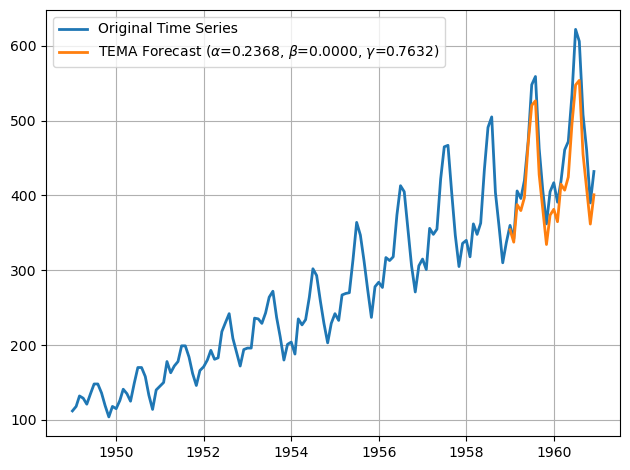

In [14]:
# Holt-Winters (triple exponential smoothing: level, trend, season) — airline passengers

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sktime.datasets import load_airline

y = load_airline()

if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()

h = 24
forecast_start = 120

y_train = y.iloc[:forecast_start]

hw_fit = ExponentialSmoothing(
    y_train.astype(float),
    trend="add",
    seasonal="add",
    seasonal_periods=12,
).fit()

hw_forecast = hw_fit.forecast(h).rename("Holt-Winters forecast")

p = hw_fit.params
alpha = float(p["smoothing_level"])
beta = float(p["smoothing_trend"])
gamma = float(p["smoothing_seasonal"])

# Plot
plt.figure()

plt.plot(y, label="Original Time Series", linewidth=2)

plt.plot(
    hw_forecast,
    label=rf"TEMA Forecast ($\alpha$={alpha:.4f}, $\beta$={beta:.4f}, $\gamma$={gamma:.4f})",
    linewidth=2,
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("HoltWinters_airline.pdf", bbox_inches="tight")

plt.show()